### Uses R v4.3.3.

# Differential expression analysis of RNA-seq Data using edgeR: A comparative study of Ryan and Yin datasets reflecting healthy versus recently recovered patients without LC symptoms.

### Introduction:
This analysis focuses on the DEGs analysis of two datasets, Ryan Et al and Yin Et al that were uniformly processed using the Bwb software, using the edgeR package set to FDR < 0.05 and a log2foldchange = 1.25.  The input sample sheet intergrates metadata from both datasets and filters the gene expression data acoordingly. The overall aim is to identify key genes that reflect significant expression differences between the two groups of participants (Healthy versus recently healed from active COVID-19 but without Long-Covid (LC) signs and symptoms).

### Specific Objectives
1. **Data Processing** - Importing and cleaning the metadata
2. **Filtering out Low Expression Genes** - Dropping genes with low expression to improve statistical power
3. **Normalization** - Using Trimmed Mean of M-values to adjust for differences in sequencing depth
4. **Differential expression analysis** - Using a negative binomial exact test (see here for the packge documentation)
5. **Extract and interpret top DEGs** - to highlight their biological relevance
6. **Set-up for downstream GSEA** - use the outputs to create rank lists for GSEA (different notebook)

![Study design](./images/Study_design.png)

### Uncomment to install BiocManager.  Comment back out after running once.  It's not necessary to reinstall every time the notebook is ran.

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install(version = "3.18")
# BiocManager::install(c("edgeR"))

### Uncomment out each package individually and run the cell to install each package.  Do this one at a time and watch the terminal output to see if any additional dependencies need to be installed on your system.  This is espeically true on Linux where you need to install other packages from the package manager.

In [2]:
# install.packages('readr', version='2.1.5')
# install.packages('dplyr', version='1.1.4')

In [3]:
library(readr)
library(dplyr)

library(edgeR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: limma



### Data Processing - Importing and cleaning the metadata

In this section, we import the normalized counts matrix from Bwb's uniform processing as our input for the Ryan Et part of the dataset.  We will later filter it to keep only the relevant samples using our sample sheet created using a different notebook.

The input file is cleaned by removing suffixes from the column headers to allow for congruence with other datasets that we will concatenate with.  We will sort the columns for consistency and then perform a sanity check by display the head to show only a few rows of the output.

## Change the Ryan Gene Counts location by updating the read.csv() value.

In [4]:
# Read Ryan counts
ryan.counts <- as.matrix(read.csv("./data/Ryan/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(ryan.counts) <- sapply(strsplit(colnames(ryan.counts), "_"), `[`, 1)

# Order the dataframe by column name
ryan.counts <- ryan.counts[, sort(colnames(ryan.counts))]

head(ryan.counts)

,SRR14076246,SRR14076247,SRR14076248,SRR14076249,SRR14076250,SRR14076251,SRR14076252,SRR14076253,SRR14076254,SRR14076255,⋯,SRR15510595,SRR15510596,SRR15510597,SRR15510598,SRR15510599,SRR15510600,SRR15510601,SRR15510602,SRR15510603,SRR15510604
ENSG00000268674,0,0,0,0,0,0,1,0,2,1,⋯,2,0,5,0,0,0,0,1,1,0
ENSG00000271254,72,50,203,199,96,130,75,76,228,181,⋯,215,318,169,146,269,241,257,154,279,94
ENSG00000275063,2,5,0,0,0,0,5,8,1,0,⋯,9,0,1,4,5,0,0,0,2,0
ENSG00000277856,0,1,0,0,0,0,2,1,0,0,⋯,0,1,0,1,1,0,0,0,0,0
ENSG00000276345,0,0,6,0,0,8,111,72,151,113,⋯,0,0,0,0,5,2,8,432,5,0
ENSG00000278633,4,0,7,7,2,0,10,0,12,2,⋯,9,8,22,1,11,16,19,2,7,0


We also want to see the dimensions of our normalized count matrix which will be useful as we concatenate with the Yin Et al dataset.  In
this case, we have 38,592 genes in the rows and 152 samples in columns all together.

In [5]:
# Sanity check to see the dimensions.
dim(ryan.counts)

[1] 38592   152

We perform similar actions with regard to the Yin Et al dataset in the next 2 cells.

## Change the Yin Gene Counts location by updating the read.csv() value.

In [6]:
# Read Yin counts
yin.counts <- as.matrix(read.csv("./data/Yin/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(yin.counts) <- sapply(strsplit(colnames(yin.counts), "_"), `[`, 1)

# Order the dataframe by column name
yin.counts <- yin.counts[, sort(colnames(yin.counts))]

head(yin.counts)

,SRR23348793,SRR23348794,SRR23348795,SRR23348796,SRR23348797,SRR23348798,SRR23348799,SRR23348800,SRR23348801,SRR23348802,⋯,SRR23348819,SRR23348820,SRR23348821,SRR23348822,SRR23348823,SRR23348824,SRR23348825,SRR23348826,SRR23348827,SRR23348828
ENSG00000268674,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSG00000271254,405,617,1183,449,673,1038,345,187,643,949,⋯,706,627,534,1330,599,453,693,476,1194,39
ENSG00000275063,6,24,45,54,4,24,0,3,51,3,⋯,4,34,2,36,25,2,14,1,72,0
ENSG00000277856,1,5,8,6,2,0,1,1,5,4,⋯,2,6,14,2,1,0,2,1,5,0
ENSG00000276345,4,0,946,613,11,5,6,0,694,7,⋯,18,14,13,0,6,2,19,4,590,3
ENSG00000278633,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


As we can see here, the number of genes (rows) in Yin Et al is also 38,592 just like in the Ryan Et al data set.  We have
fewer total samples (columns) with only 36 as oppossed to Ryan Et al which had 152 samples.  The process of subsetting will lead to a more
balanced dataset compendium for comparison.

In [7]:
# Sanity check to see the dimensions of the dataset
dim(yin.counts)

[1] 38592    36

### Loading the metadata

Now that we have the normalized data with counts matrix from each group (Ryan and Yin), we need the metadata which will guide us in 
subsetting our data with respect to clinical attributes like presence or absence of LC, LC severity classification etc. We include the sample sheets for our desired comparisons which are those that were healthy and the recently healed without any LC signs and symptoms.

We also prepare the metadata dataset by removing the extra index column, combining all relevant sample sheets for inclusion, then sorting by sample name "Run".

## Change the Compendium metadata locations by updating the read_tsv() values.

In [8]:
# Read Andrew's Compendium data: Group A - Ryan
sample.sheet.healthy.af = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_af.csv")
sample.sheet.healthy.am = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_am.csv")

# Remove first column from dataframes
sample.sheet.healthy.af <- sample.sheet.healthy.af[c(2:length(colnames(sample.sheet.healthy.af)))]
sample.sheet.healthy.am <- sample.sheet.healthy.am[c(2:length(colnames(sample.sheet.healthy.am)))]

# Concatenate dataframes
ryan.sample.sheet.healthy <- rbind(sample.sheet.healthy.af, sample.sheet.healthy.am)

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.healthy <- arrange(ryan.sample.sheet.healthy, Run)

ryan.sample.sheet.healthy

New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


We then subset the output to only include the the sample name "Run" and "disease-severity" columns where we only want
those that are healthy.  There are 14 cases that fit this criteria.

In [9]:
# Reduce and convert ryan_sample_sheet_healthy into sheet that can be concatenated
ryan.sample.sheet.healthy.reduced = ryan.sample.sheet.healthy[c("Run", "disease_severity")]

# Change disease_severity column name to lc_status
colnames(ryan.sample.sheet.healthy.reduced)[2] <- "lc_status"
                                            
ryan.sample.sheet.healthy.reduced                         

Run,lc_status
<chr>,<chr>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


We perform the same operations on the Yin Et al dataset to yield 13 samples where participants had healed from Acute
COVID-19 and had no evidence of LC.

## Change the Compendium metadata locations by updating the read_tsv() values.

In [10]:
# Read Andrew's Compendium data: Group B - Yin
yin.bulk.metadata.bnonlcf = read_tsv("./Andrews_Compendium/output/yin_bulk_metadata_bnonlcf.csv")
yin.bulk.metadata.bnonlcm = read_tsv("./Andrews_Compendium/output/yin_bulk_metadata_bnonlcm.csv")

# Remove first column from dataframes
yin.bulk.metadata.bnonlcf <- yin.bulk.metadata.bnonlcf[c(2:length(colnames(yin.bulk.metadata.bnonlcf)))]
yin.bulk.metadata.bnonlcm <- yin.bulk.metadata.bnonlcm[c(2:length(colnames(yin.bulk.metadata.bnonlcm)))]

# Concatenate dataframes
yin.bulk.metadata.nonlc <- rbind(yin.bulk.metadata.bnonlcf, yin.bulk.metadata.bnonlcm)

# Sort dataframe by Run (Sample) column
yin.bulk.metadata.nonlc <- arrange(yin.bulk.metadata.nonlc, Run)

yin.bulk.metadata.nonlc

New names:
• `` -> `...1`
Rows: 5 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, cell_type, Center Name, C...
dbl   (6): ...1, AvgSpotLen, Bases, Bytes, PID, version
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 8 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, cell_type, Center Name, C...
dbl   (6): ...1, AvgSpotLen, Bases, Bytes, PID, version
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Consent,⋯,PID,Platform,ReleaseDate,create_date,version,Sample Name,sex,source_name,SRA Study,tissue
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<dttm>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR23348797,RNA-Seq,300,12555716700,PRJNA931952,SAMN33139458,4079493239,PBMC,GLADSTONE INSTITUTES,public,⋯,5221,ILLUMINA,2023-02-09,2023-02-06 12:32:00,1,GSM7027509,male,Total PBMC,SRP421156,Total PBMC
SRR23348798,RNA-Seq,300,14466878400,PRJNA931952,SAMN33139459,4656879835,PBMC,GLADSTONE INSTITUTES,public,⋯,5206,ILLUMINA,2023-02-09,2023-02-06 12:21:00,1,GSM7027508,female,Total PBMC,SRP421156,Total PBMC
SRR23348808,RNA-Seq,300,8097540600,PRJNA931952,SAMN33139469,2518682513,PBMC,GLADSTONE INSTITUTES,public,⋯,5120,ILLUMINA,2023-02-09,2023-02-06 12:09:00,1,GSM7027498,male,Total PBMC,SRP421156,Total PBMC
SRR23348809,RNA-Seq,300,12582225300,PRJNA931952,SAMN33139470,4086945083,PBMC,GLADSTONE INSTITUTES,public,⋯,5103,ILLUMINA,2023-02-09,2023-02-06 12:24:00,1,GSM7027497,male,Total PBMC,SRP421156,Total PBMC
SRR23348813,RNA-Seq,300,14331609900,PRJNA931952,SAMN33139474,4660378951,PBMC,GLADSTONE INSTITUTES,public,⋯,5082,ILLUMINA,2023-02-09,2023-02-06 12:28:00,1,GSM7027493,male,Total PBMC,SRP421156,Total PBMC
SRR23348819,RNA-Seq,300,15600924900,PRJNA931952,SAMN33139480,5069580833,PBMC,GLADSTONE INSTITUTES,public,⋯,5053,ILLUMINA,2023-02-09,2023-02-06 12:32:00,1,GSM7027487,male,Total PBMC,SRP421156,Total PBMC
SRR23348821,RNA-Seq,300,12899724300,PRJNA931952,SAMN33139482,4110331750,PBMC,GLADSTONE INSTITUTES,public,⋯,5048,ILLUMINA,2023-02-09,2023-02-06 12:24:00,1,GSM7027485,male,Total PBMC,SRP421156,Total PBMC
SRR23348822,RNA-Seq,300,14532012000,PRJNA931952,SAMN33139483,4702495979,PBMC,GLADSTONE INSTITUTES,public,⋯,5044,ILLUMINA,2023-02-09,2023-02-06 12:22:00,1,GSM7027484,female,Total PBMC,SRP421156,Total PBMC
SRR23348824,RNA-Seq,300,10164895500,PRJNA931952,SAMN33139485,3219695578,PBMC,GLADSTONE INSTITUTES,public,⋯,5035,ILLUMINA,2023-02-09,2023-02-06 12:13:00,1,GSM7027482,male,Total PBMC,SRP421156,Total PBMC


In [11]:
# Reduce and convert yin_bulk_metadata_nonlc into sheet that can be concatenated
yin.bulk.metadata.nonlc.reduced = yin.bulk.metadata.nonlc[c("Run", "lc_status")]
yin.bulk.metadata.nonlc.reduced$lc_status <- replace(yin.bulk.metadata.nonlc.reduced$lc_status, yin.bulk.metadata.nonlc.reduced$lc_status == "Non-LC", "Non_LC")
                                            
yin.bulk.metadata.nonlc.reduced             

Run,lc_status
<chr>,<chr>
SRR23348797,Non_LC
SRR23348798,Non_LC
SRR23348808,Non_LC
SRR23348809,Non_LC
SRR23348813,Non_LC
SRR23348819,Non_LC
SRR23348821,Non_LC
SRR23348822,Non_LC
SRR23348824,Non_LC


Here, we will combine the Ryan and Yin subsetted datasets into one using rbind().  We will then make the disease severity
attribute our factor in preparation for analysis (lc_status). Finally we will do a sanity check for visual reassurance.

In [12]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.counts.of.interest <- ryan.counts[, ryan.sample.sheet.healthy$Run]

head(ryan.counts.of.interest)

,SRR14076274,SRR14076275,SRR14076280,SRR14076281,SRR14076285,SRR14076286,SRR14076291,SRR14076292,SRR14076319,SRR14076320,SRR14076325,SRR14076326,SRR14076331,SRR14076332
ENSG00000268674,0,0,0,2,0,0,0,0,1,0,0,0,0,1
ENSG00000271254,153,68,59,141,87,127,97,161,129,149,71,271,138,178
ENSG00000275063,0,0,0,0,0,2,5,10,14,1,8,2,8,0
ENSG00000277856,0,0,0,0,0,4,0,0,1,1,1,1,1,0
ENSG00000276345,0,110,80,0,2,2,0,239,0,2,7,0,140,149
ENSG00000278633,0,14,2,6,2,0,0,0,6,0,1,12,0,0


In [13]:
# Create dataframe from Gene Counts that only contains samples from compendium
yin.counts.of.interest <- yin.counts[, yin.bulk.metadata.nonlc$Run]

head(yin.counts.of.interest)

,SRR23348797,SRR23348798,SRR23348808,SRR23348809,SRR23348813,SRR23348819,SRR23348821,SRR23348822,SRR23348824,SRR23348825,SRR23348826,SRR23348827,SRR23348828
ENSG00000268674,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000271254,673,1038,139,493,297,706,534,1330,453,693,476,1194,39
ENSG00000275063,4,24,7,2,101,4,2,36,2,14,1,72,0
ENSG00000277856,2,0,1,1,7,2,14,2,0,2,1,5,0
ENSG00000276345,11,5,0,423,354,18,13,0,2,19,4,590,3
ENSG00000278633,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
# Concatinate Ryan and Yin counts of interest
counts.of.interest <- cbind(ryan.counts.of.interest, yin.counts.of.interest)

dim(counts.of.interest)

[1] 38592    27

We then perform a filtering step that removes any rows of genes that conatin all zeros in every column.  This will not affect
analysis negatively and will save on computational resources during iterative analysis. As we can see below. This step reduced the
dimensions of the dataframe to 33,428 genes (rows) from 38,592 while keeping the 27 total samples.

In [15]:
# Remove Genes that only contain 0s
counts.of.interest.filtered <- counts.of.interest[apply(counts.of.interest != 0, 1, sum) != 0,]
dim(counts.of.interest.filtered)

[1] 33428    27

In [16]:
# Concatinate Ryan and Yin metadata
metadata <- rbind(ryan.sample.sheet.healthy.reduced, yin.bulk.metadata.nonlc.reduced)

metadata$lc_status <- factor(metadata$lc_status)

metadata

Run,lc_status
<chr>,<fct>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


Next, we will create a DGEList object which will be the foundation of our analysis.  This method (See help() of the package) will help us filter genes based on expression levels, normalize the gene counts, create a design matrix for comparison, then it will estimate dispersion
(which is the variance in gene expression).  After this, it will perform statistical testing.

In [17]:
# Defining two groups and assigning to the variable "group"
group <- factor(c(rep(1,14), rep(2, 13)))

In [18]:
# Preparing the data for normalization, filtering, and DEA
y <- DGEList(counts=counts.of.interest.filtered, group=group)

In [19]:
# Filtering out genes to keep only those with more than 3 copies per million in at least 5 samples.
dim(y)
keep <- rowSums(cpm(y)>3) > 5
table(keep)

[1] 33428    27

keep
FALSE  TRUE 
20185 13243 

In [20]:
# Removing those genes that were filter out to only keep the 13,243 genes
y <- y[keep, , keep.lib.sizes=FALSE]
tokeep = rownames(y)
dim(y)

[1] 13243    27

In [21]:
# Normalization with edgeR
y <- calcNormFactors(y)

In [22]:
# Creating the Design matrix
design <- model.matrix(~group)

In [23]:
# Estimating dispersions
y <- estimateDisp(y)

Using classic mode.



In [24]:
# Inferring differential expression
et <- exactTest(y)

In [25]:
# Subsetting top DEGs
top20.genes <- rownames(topTags(et, n=20)$table)
top50.genes <- rownames(topTags(et, n=50)$table)
top100.genes <- rownames(topTags(et, n=100)$table)

In [26]:
# Obtaining expression levels of top 20 genes from counts of interest
raw.cnts.top20 <- counts.of.interest[top20.genes, ]

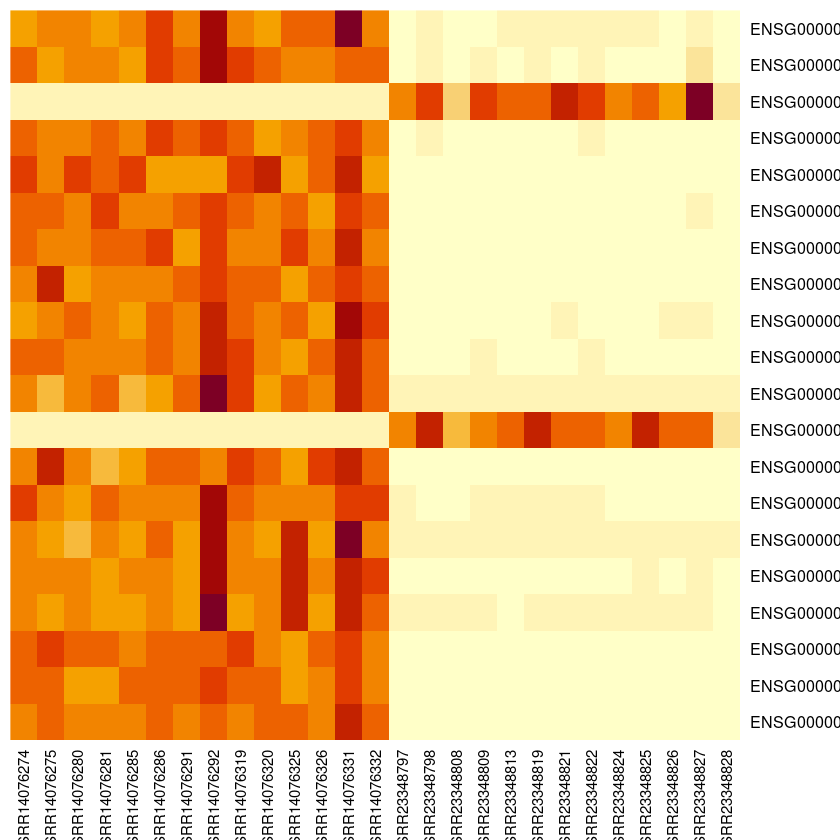

In [27]:
# Heatmap visualization of top 20 genes
heatmap(as.matrix(raw.cnts.top20), Colv=NA, Rowv=NA)

In [28]:
# Obtaining expression levels of top 50 genes from counts of interest
raw.cnts.top50 <- counts.of.interest[top50.genes, ]

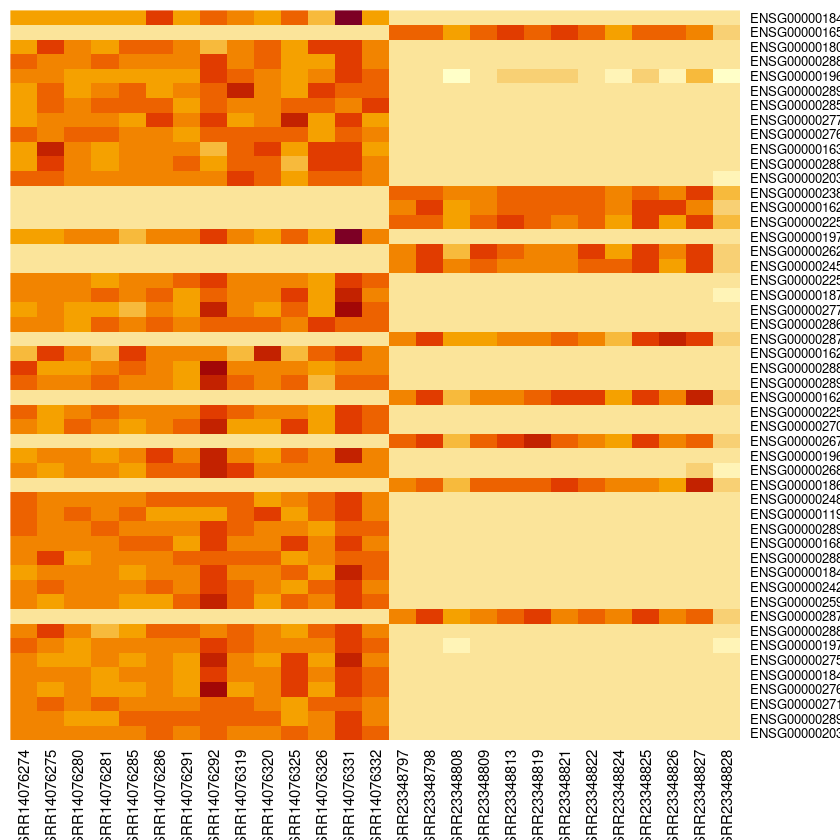

In [29]:
# Heatmap visualization of top 50 genes
heatmap(as.matrix(raw.cnts.top50), Colv=NA, Rowv=NA)

In [30]:
# Obtaining expression levels of top 100 genes from counts of interest
raw.cnts.top100 <- counts.of.interest[top100.genes, ]

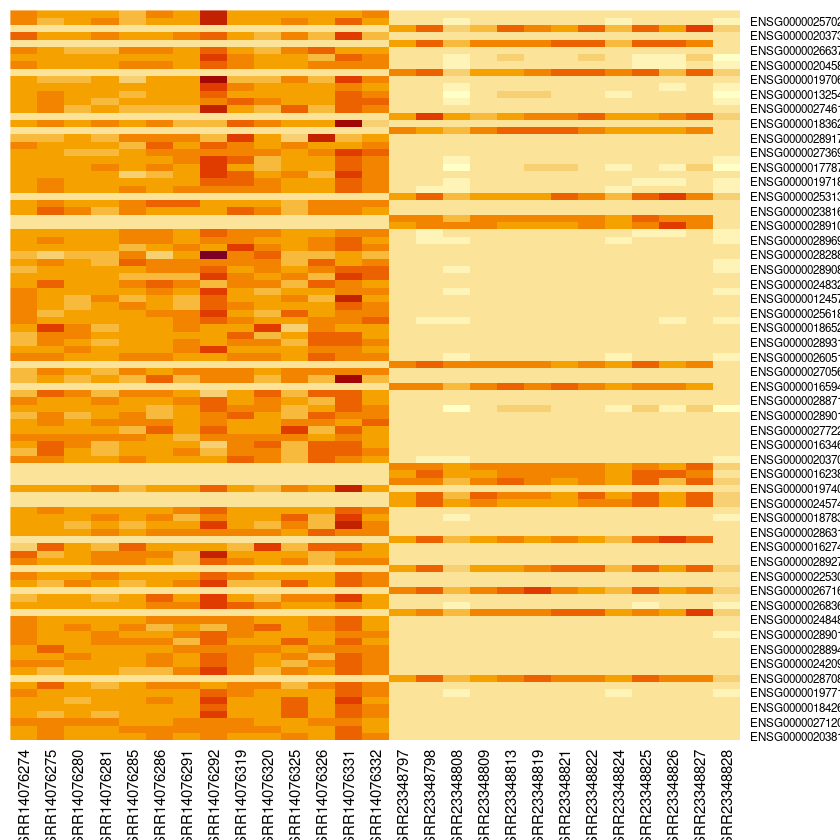

In [31]:
# Heatmap visualization of top 100 genes
heatmap(as.matrix(raw.cnts.top100), Colv=NA, Rowv=NA)

In [32]:
# Extracting the top differentially expressed genes
deg_results_AvsB <- topTags(et, n = Inf)$table
head(deg_results_AvsB)

,logFC,logCPM,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000203814,-8.127489,5.125324,0.000000e+00,0.000000e+00
ENSG00000289702,-7.573192,3.994448,0.000000e+00,0.000000e+00
ENSG00000271204,-7.290199,4.193909,0.000000e+00,0.000000e+00
ENSG00000276966,-6.765358,5.134445,0.000000e+00,0.000000e+00
ENSG00000184260,-5.692843,5.823836,0.000000e+00,0.000000e+00
ENSG00000275379,-8.493242,3.677613,1.107595e-307,2.444647e-304


### Notice

The next slide can be saved as a .csv excel spread sheet by uncommenting the code snippet while leaving the comment with the '#'.

In [33]:
# Ensure row names (gene IDs) are saved as a column
#deg_results_AvsB$GeneID <- rownames(deg_results_AvsB)

# Save the file with GeneID included
#write.csv(deg_results_AvsB, file = file.path(getwd(), "deg_results_AvsB.csv"), row.names = FALSE)
